# 03 — Classificação e Avaliação
Carrega `X.csv` e `y.csv` gerados no notebook 02 e treina dois classificadores clássicos:
- **KNN** (K-Nearest Neighbors)
- **Random Forest**

Inclui (nível intermediário):
- Divisão estratificada train / val / test
- StandardScaler ajustado apenas no treino
- Validação cruzada
- Ajuste de hiperparâmetros com GridSearchCV
- Métricas: acurácia, precisão, recall, F1, matriz de confusão, curva ROC
- Importância de features do Random Forest
- Tabela comparativa final
- Análise de erros: 5 imagens em que o modelo errou

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc,
    classification_report
)

OUTPUT_DIR = Path('../outputs')
OUTPUT_DIR.mkdir(exist_ok=True)
SEED = 42

## Carrega dados

In [23]:
X = pd.read_csv(OUTPUT_DIR / 'X.csv').fillna(0)
y = pd.read_csv(OUTPUT_DIR / 'y.csv').squeeze()

le = LabelEncoder()
y_enc = le.fit_transform(y)   # fresh=0, rotten=1 (ordem alfabética)
classes = le.classes_

print(f'X: {X.shape}  |  classes: {classes}')
print(pd.Series(y).value_counts())

X: (27398, 23)  |  classes: ['fresh' 'freshapples' 'freshbanana' 'freshoranges' 'rotten'
 'rottenapples' 'rottenbanana' 'rottenoranges']
classe
rottenapples     5886
rottenbanana     5508
freshapples      4176
rottenoranges    3996
freshbanana      3924
freshoranges     3708
fresh             100
rotten            100
Name: count, dtype: int64


## Divisão estratificada: 70% treino / 15% val / 15% teste

In [24]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y_enc, test_size=0.15, stratify=y_enc, random_state=SEED)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15/0.85, stratify=y_temp, random_state=SEED)

print(f'Treino: {len(X_train)}  |  Val: {len(X_val)}  |  Teste: {len(X_test)}')

# Scaler ajustado APENAS no treino — evita vazamento de dados
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

Treino: 19178  |  Val: 4110  |  Teste: 4110


## Funções auxiliares

In [25]:
def avaliar(nome, modelo, X_tr, y_tr, X_te, y_te):
    modelo.fit(X_tr, y_tr)
    y_pred = modelo.predict(X_te)
    return {
        'modelo':    nome,
        'acuracia':  round(accuracy_score(y_te, y_pred), 4),
        'precisao':  round(precision_score(y_te, y_pred, average='weighted', zero_division=0), 4),
        'recall':    round(recall_score(y_te, y_pred, average='weighted', zero_division=0), 4),
        'f1':        round(f1_score(y_te, y_pred, average='weighted', zero_division=0), 4),
    }

def plot_confusao(nome, modelo, X_te, y_te, classes):
    y_pred = modelo.predict(X_te)
    cm = confusion_matrix(y_te, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=classes)
    fig, ax = plt.subplots(figsize=(5,4))
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Matriz de Confusão — {nome}')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'confusao_{nome.lower().replace(" ","_")}.png', dpi=150)
    plt.show()

def plot_roc(nome, modelo, X_te, y_te, classes):
    """ROC macro-average para multiclasse (one-vs-rest)."""
    y_bin = label_binarize(y_te, classes=range(len(classes)))
    y_prob = modelo.predict_proba(X_te)

    fpr_list, tpr_list, roc_auc_list = [], [], []
    for i in range(len(classes)):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
        fpr_list.append(fpr)
        tpr_list.append(tpr)
        roc_auc_list.append(auc(fpr, tpr))

    # Macro average
    mean_auc = np.mean(roc_auc_list)
    plt.plot(fpr_list[0], tpr_list[0], alpha=0.0)  # dummy para escala
    for i, cls in enumerate(classes):
        plt.plot(fpr_list[i], tpr_list[i], alpha=0.5, label=f'{nome} — {cls} (AUC={roc_auc_list[i]:.3f})')
    return mean_auc

## GridSearchCV — ajuste de hiperparâmetros
Roda na validação cruzada do conjunto de treino. O conjunto de teste não é tocado ainda.

In [26]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# KNN
grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid={'n_neighbors': [3, 5, 7, 11], 'weights': ['uniform', 'distance']},
    cv=cv, scoring='f1_weighted', n_jobs=-1
)
grid_knn.fit(X_train_s, y_train)
print(f'KNN — melhor params: {grid_knn.best_params_}  |  F1 val: {grid_knn.best_score_:.4f}')

# Random Forest
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=SEED),
    param_grid={'n_estimators': [100, 200], 'max_depth': [None, 10, 20]},
    cv=cv, scoring='f1_weighted', n_jobs=-1
)
grid_rf.fit(X_train_s, y_train)
print(f'RF  — melhor params: {grid_rf.best_params_}  |  F1 val: {grid_rf.best_score_:.4f}')

KNN — melhor params: {'n_neighbors': 3, 'weights': 'distance'}  |  F1 val: 0.9634
RF  — melhor params: {'max_depth': 20, 'n_estimators': 200}  |  F1 val: 0.9849


## Validação cruzada com os melhores modelos

In [27]:
knn_best = grid_knn.best_estimator_
rf_best  = grid_rf.best_estimator_

for nome, modelo in [('KNN', knn_best), ('Random Forest', rf_best)]:
    scores = cross_val_score(modelo, X_train_s, y_train, cv=cv, scoring='f1_weighted')
    print(f'{nome}: F1 CV = {scores.mean():.4f} ± {scores.std():.4f}')

KNN: F1 CV = 0.9634 ± 0.0024
Random Forest: F1 CV = 0.9849 ± 0.0011


## Avaliação final no conjunto de teste
> ⚠️ Execute esta célula apenas uma vez. O teste é reservado para avaliação final.

In [28]:
resultados = []
for nome, modelo in [('KNN', knn_best), ('Random Forest', rf_best)]:
    modelo.fit(X_train_s, y_train)   # retreina no treino completo
    r = avaliar(nome, modelo, X_train_s, y_train, X_test_s, y_test)
    resultados.append(r)
    print(f'\n=== {nome} ===')
    print(classification_report(y_test, modelo.predict(X_test_s), target_names=classes))

tabela = pd.DataFrame(resultados).set_index('modelo')
print('\n=== Tabela comparativa ===')
print(tabela.to_string())
tabela.to_csv(OUTPUT_DIR / 'metricas_comparativo.csv')


=== KNN ===
               precision    recall  f1-score   support

        fresh       0.00      0.00      0.00        15
  freshapples       0.96      0.95      0.96       627
  freshbanana       0.98      0.99      0.99       589
 freshoranges       0.98      0.97      0.97       556
       rotten       0.00      0.00      0.00        15
 rottenapples       0.95      0.96      0.96       883
 rottenbanana       1.00      1.00      1.00       826
rottenoranges       0.98      0.96      0.97       599

     accuracy                           0.96      4110
    macro avg       0.73      0.73      0.73      4110
 weighted avg       0.97      0.96      0.97      4110


=== Random Forest ===
               precision    recall  f1-score   support

        fresh       0.00      0.00      0.00        15
  freshapples       0.98      0.99      0.98       627
  freshbanana       1.00      1.00      1.00       589
 freshoranges       1.00      1.00      1.00       556
       rotten       0.00 

## Matrizes de confusão

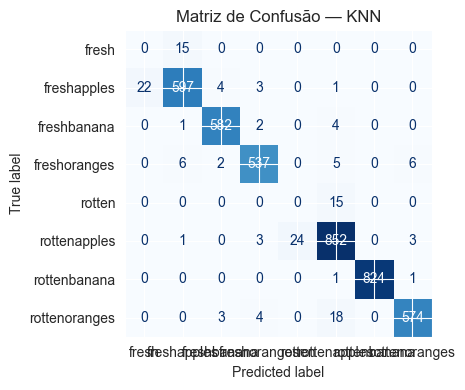

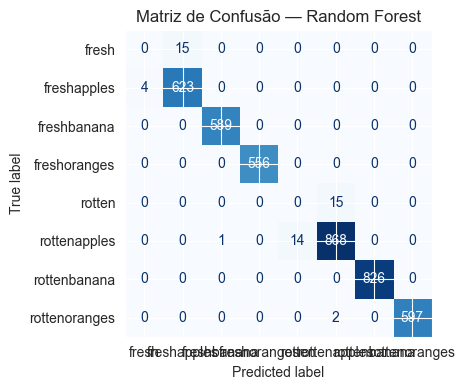

In [29]:
for nome, modelo in [('KNN', knn_best), ('Random Forest', rf_best)]:
    plot_confusao(nome, modelo, X_test_s, y_test, classes)

## Curva ROC

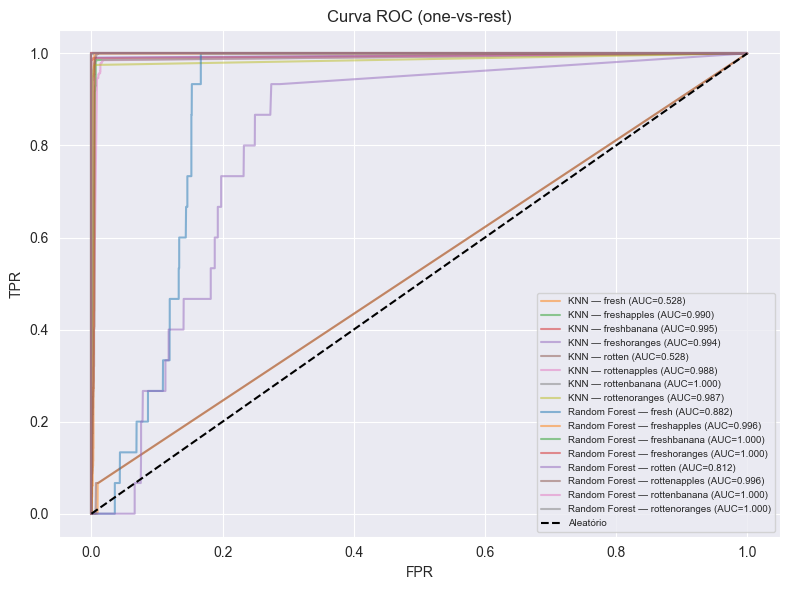

In [30]:
plt.figure(figsize=(8,6))
for nome, modelo in [('KNN', knn_best), ('Random Forest', rf_best)]:
    plot_roc(nome, modelo, X_test_s, y_test, classes)
plt.plot([0,1],[0,1],'k--', label='Aleatório')
plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('Curva ROC (one-vs-rest)')
plt.legend(fontsize=7); plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'curva_roc.png', dpi=150)
plt.show()

## Importância de features — Random Forest

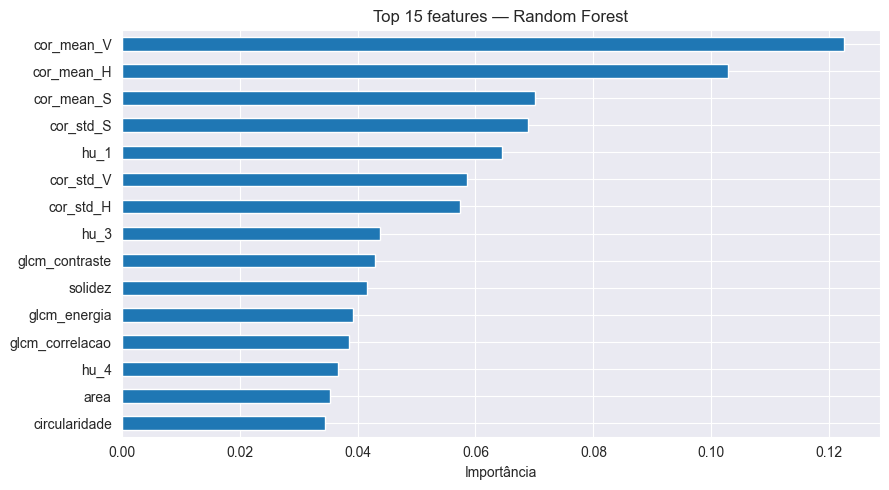

cor_mean_V         0.122470
cor_mean_H         0.102869
cor_mean_S         0.070148
cor_std_S          0.068991
hu_1               0.064434
cor_std_V          0.058531
cor_std_H          0.057445
hu_3               0.043860
glcm_contraste     0.043025
solidez            0.041682
glcm_energia       0.039196
glcm_correlacao    0.038542
hu_4               0.036693
area               0.035381
circularidade      0.034515


In [31]:
importancias = pd.Series(rf_best.feature_importances_, index=X.columns)
importancias = importancias.sort_values(ascending=False).head(15)

plt.figure(figsize=(9,5))
importancias[::-1].plot(kind='barh')
plt.xlabel('Importância')
plt.title('Top 15 features — Random Forest')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'rf_importancia_features.png', dpi=150)
plt.show()
print(importancias.to_string())

## Análise de erros
Mostra até 5 imagens em que o Random Forest errou, com rótulo real vs predito.
Útil para identificar padrões de falha e discutir limitações no relatório.

Total de erros no teste: 51 de 4110


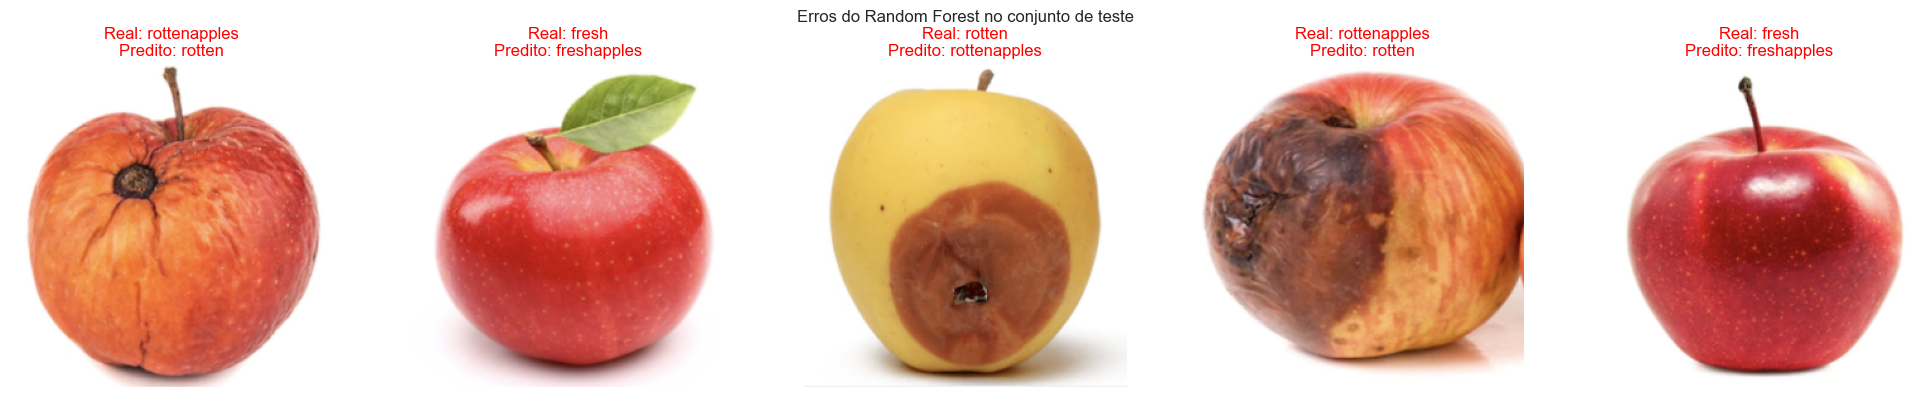

In [32]:
import cv2
from pathlib import Path

DATA_DIR = Path('../data')
imagens_all = list(DATA_DIR.rglob('*.jpg')) + list(DATA_DIR.rglob('*.jpeg')) + list(DATA_DIR.rglob('*.png'))

# Reconstrói o índice original para mapear de volta às imagens
X_full = pd.read_csv(OUTPUT_DIR / 'X.csv').fillna(0)
y_full = pd.read_csv(OUTPUT_DIR / 'y.csv').squeeze()

# Usa os índices do conjunto de teste
X_test_orig = X_full.iloc[X_test.index] if hasattr(X_test, 'index') else X_full.loc[X_test.index]
y_pred_test = rf_best.predict(X_test_s)
y_real_test = y_test

erros_idx = np.where(y_pred_test != y_real_test)[0]
print(f'Total de erros no teste: {len(erros_idx)} de {len(y_test)}')

# Tenta mostrar imagens dos erros (requer que as imagens ainda estejam em data/)
amostras_erro = erros_idx[:5]
if len(amostras_erro) > 0 and len(imagens_all) > 0:
    # Mapeia índice do teste de volta ao índice global
    indices_globais = list(X_test.index) if hasattr(X_test, 'index') else list(range(len(X_test)))
    fig, axes = plt.subplots(1, len(amostras_erro), figsize=(4*len(amostras_erro), 4))
    if len(amostras_erro) == 1: axes = [axes]
    for ax, err_i in zip(axes, amostras_erro):
        global_i = indices_globais[err_i]
        if global_i < len(imagens_all):
            img = cv2.imread(str(imagens_all[global_i]))
            img = cv2.resize(img, (256,256))
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        real  = classes[y_real_test[err_i]]
        pred  = classes[y_pred_test[err_i]]
        ax.set_title(f'Real: {real}\nPredito: {pred}', color='red')
        ax.axis('off')
    plt.suptitle('Erros do Random Forest no conjunto de teste', fontsize=12)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'analise_erros.png', dpi=150)
    plt.show()
else:
    print('Nenhum erro encontrado ou imagens não localizadas.')

## Conclusão

Preencha com base nos seus resultados:

- **Melhor modelo:** *(ex: Random Forest, F1=0.94)*
- **Por que escolheria em produção:** *(ex: maior recall para rotten — é pior deixar fruta podre passar do que descartar uma boa)*
- **Principais features discriminativas:** *(veja gráfico de importância acima)*
- **Limitações:** *(ex: segmentação falha em frutas muito escuras, dataset pequeno)*
- **Possíveis melhorias:** *(ex: aumentar dataset, testar LBP, ajustar threshold HSV por tipo de fruta)*